# Machine learning for Regression

In [1]:
import pandas as pd
import numpy as np

In [69]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

In [70]:
!wget $data

--2026-05-17 10:38:26--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8001::154, 2606:50c0:8002::154, 2606:50c0:8003::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8001::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1475504 (1.4M) [text/plain]
Saving to: ‘data.csv.1’

data.csv.1          100%[===================>]   1.41M  --.-KB/s    in 0.1s    

2026-05-17 10:38:26 (9.91 MB/s) - ‘data.csv.1’ saved [1475504/1475504]



In [71]:
df = pd.read_csv('data.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [72]:
# changing the column names to lower case and replacing spaces with underscores
df.columns = df.columns.str.replace(' ', '_').str.lower()

df.dtypes[df.dtypes == 'str']


make                 str
model                str
engine_fuel_type     str
transmission_type    str
driven_wheels        str
market_category      str
vehicle_size         str
vehicle_style        str
dtype: object

In [73]:
strings = list(df.dtypes[df.dtypes == 'str'].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [74]:
for col in strings:
    df[col] = df[col].str.replace(' ', '_').str.lower()

In [75]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


# Data Summary 

In [76]:
summary = []
for col in df.columns:
    values = df[col].dropna().unique()[:5]

    summary.append({
        "column": col,
        "dtype": str(df[col].dtype),
        "unique_count": df[col].nunique(),
        "null_values": df[col].isnull().sum(),
        "examples": ", ".join(map(str, values))
    })

summary_df = pd.DataFrame(summary)

summary_df

,column,dtype,unique_count,null_values,examples
0,make,str,48,0,"bmw, audi, fiat, mercedes-benz, chrysler"
1,model,str,914,0,"1_series_m, 1_series, 100, 124_spider, 190-class"
2,year,int64,28,0,"2011, 2012, 2013, 1992, 1993"
3,engine_fuel_type,str,10,3,"premium_unleaded_(required), regular_unleaded,..."
4,engine_hp,float64,356,69,"335.0, 300.0, 230.0, 320.0, 172.0"
5,engine_cylinders,float64,9,30,"6.0, 4.0, 5.0, 8.0, 12.0"
6,transmission_type,str,5,0,"manual, automatic, automated_manual, direct_dr..."
7,driven_wheels,str,4,0,"rear_wheel_drive, front_wheel_drive, all_wheel..."
8,number_of_doors,float64,3,6,"2.0, 4.0, 3.0"
9,market_category,str,71,3742,"factory_tuner,luxury,high-performance, luxury,..."


# Price Distribution

In [77]:
import matplotlib.pyplot as plt 
import seaborn as sns

%matplotlib inline 

<Axes: xlabel='msrp', ylabel='Count'>

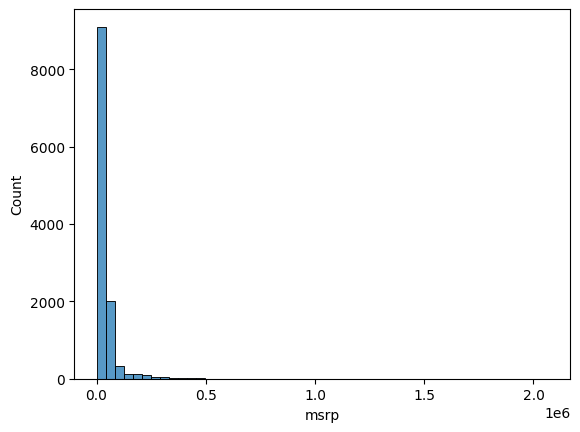

In [78]:
sns.histplot(df.msrp, bins = 50)

<Axes: xlabel='msrp', ylabel='Count'>

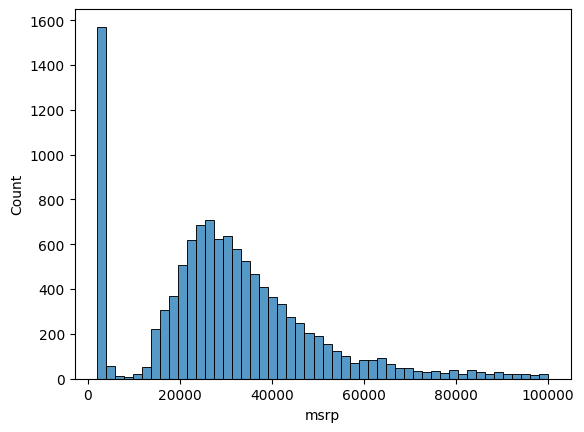

In [79]:
sns.histplot(df.msrp[df.msrp < 100000], bins = 50)

## Long-Tail Distribution Summary

A **long-tail distribution** means most values are concentrated in a small range, while a few values are extremely large.

In the `msrp` price distribution, most cars have low or normal prices, but a small number of cars are very expensive. This creates a long tail on the right side of the histogram, also called a **right-skewed distribution**.

## Why It Matters in Machine Learning

Long-tail distributions can cause problems because:

- The model learns common low-price examples better than rare expensive examples.
- Very large values can strongly affect the loss function.
- Metrics like RMSE can be misleading because they are sensitive to extreme values.
- The model may perform poorly on rare high-value cases.

## Common Solution

A standard solution is to apply a **log transformation** to the target variable to make it a normal distribution:

```python
y = np.log1p(x)

<Axes: xlabel='msrp', ylabel='Count'>

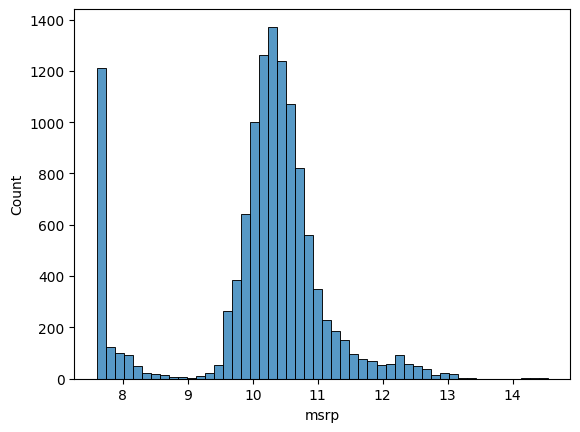

In [80]:
price_logs = np.log1p(df.msrp)
sns.histplot(price_logs, bins = 50)

## Validation Framework: 60/20/20 Split

A validation framework helps us evaluate machine learning models fairly.

The dataset is usually split into:

- **60% Training Set**: used to train the model.
- **20% Validation Set**: used to compare models and tune parameters.
- **20% Test Set**: used only at the end for the final evaluation.

The training set teaches the model patterns.

The validation set helps us choose the best model and avoid overfitting.

The test set gives a final estimate of how the model performs on new, unseen data.

We should not use the test set during model development, because it must remain unseen for a fair final check.

In [81]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [82]:
n_val, n_test, n_train

(2382, 2382, 7150)

In [83]:
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]

In [84]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,mazda,navajo,1994,regular_unleaded,160.0,6.0,manual,four_wheel_drive,2.0,NaN,compact,2dr_suv,18,14,586,2000
7146,mazda,navajo,1994,regular_unleaded,160.0,6.0,manual,four_wheel_drive,2.0,NaN,compact,2dr_suv,18,14,586,2000
7147,lincoln,navigator,2015,regular_unleaded,365.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,65055
7148,lincoln,navigator,2015,regular_unleaded,365.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,67220


In [86]:
idx = np.arange(n)

In [87]:
np.random.seed(2)
np.random.shuffle(idx)

In [92]:
df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val = df.iloc[idx[n_train:n_train+n_val]].reset_index(drop=True)
df_test = df.iloc[idx[n_train+n_val:]].reset_index(drop=True)

In [93]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916,54900
7146,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873,29215
7147,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549,34675
7148,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86,303300


In [90]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [97]:
y_train = np.log1p(df_train.msrp.values)
y_test = np.log1p(df_test.msrp.values)
y_val = np.log1p(df_val.msrp.values)

In [ ]:
# delete the msrp column to avoid using it 
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

# Linear Regression

In [103]:
df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

In [104]:
xi = [453, 11, 86]
w0 = 7.17
w = [0.01, 0.04, 0.002]
    

In [105]:
def linear_regression(xi):
    n = len(xi)

    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j]

    return pred

In [106]:
linear_regression(xi)

12.312

In [108]:
np.expm1(12.312)

np.float64(222347.2221101062)

In [141]:
def dot(xi, w):
    n = len(xi)
    res = 0.0

    for j in range(n):
        res = res + xi[j] * w[j]

    return res


def linear_regression(xi):
    return w0 + dot(xi, w)

In [142]:
linear_regression(xi)

12.312000000000001

# Linear regression vector form

In [145]:

w_new = [w0] + w

def dot(xi, w):
    n = len(xi)
    res = 0.0

    for j in range(n):
        res = res + xi[j] * w[j]

    return res


def linear_regression(xi):
    xi = [1] + xi
    return dot(xi, w_new)

# Training the Model 

# Normal Equation vs Gradient Descent

Both methods are used to find the best weights for linear regression.

The **normal equation** finds the weights directly using:

`w = (XᵀX)⁻¹ Xᵀy`

It is a one-step mathematical solution. It does not need a learning rate or repeated updates, but it can become slow when the dataset has many features because it requires matrix inversion.

**Gradient descent** finds the weights step by step. It starts with initial weights, calculates the error, and updates the weights many times until the model improves.

Main difference:

- Normal equation: solves directly in one step.
- Gradient descent: learns gradually through many iterations.

Normal equation is simple and useful for smaller datasets. Gradient descent is more flexible and better for large datasets or complex models like neural networks.

In [178]:
def train_linear_regression(X, y):
    pass

In [198]:
y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]
X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [180]:
ones = np.ones(X.shape[0])
ones 

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [181]:
X = np.column_stack([ones, X])
X

array([[1.000e+00, 1.480e+02, 2.400e+01, 1.385e+03],
       [1.000e+00, 1.320e+02, 2.500e+01, 2.031e+03],
       [1.000e+00, 4.530e+02, 1.100e+01, 8.600e+01],
       [1.000e+00, 1.580e+02, 2.400e+01, 1.850e+02],
       [1.000e+00, 1.720e+02, 2.500e+01, 2.010e+02],
       [1.000e+00, 4.130e+02, 1.100e+01, 8.600e+01],
       [1.000e+00, 3.800e+01, 5.400e+01, 1.850e+02],
       [1.000e+00, 1.420e+02, 2.500e+01, 4.310e+02],
       [1.000e+00, 4.530e+02, 3.100e+01, 8.600e+01]])

In [182]:
# we want to calculate `w = (XᵀX)⁻¹ Xᵀy`
# first the invers of the Gram Matrix (XᵀX)⁻¹
XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)

In [183]:
XTX_inv.dot(XTX).round(1)

array([[ 1., -0., -0.,  0.],
       [ 0.,  1., -0.,  0.],
       [ 0.,  0.,  1., -0.],
       [ 0.,  0., -0.,  1.]])

In [184]:
# now the full formula `(XᵀX)⁻¹ Xᵀy`
w_full = XTX_inv.dot(X.T).dot(y)

In [191]:
w0 = w_full[0]
w = w_full[1:]

In [192]:
w0, w

(np.float64(25844.754055766753),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

In [199]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

In [200]:
train_linear_regression(X, y)

(np.float64(25844.754055766753),
 array([ -16.08906468, -199.47254894,   -1.22802883]))